# Differential Equations in Biochemistry: Deriving Michaelis-Menten

The Michaelis-Menten rate law

$$v = \frac{V_{max} S}{K_m + S}$$

is usually just handed to students. Here it's **derived**, not assumed: the
full elementary mass-action mechanism

$$E + S \underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}} ES \xrightarrow{k_2} E + P$$

is a 4-species nonlinear ODE system, integrated by hand-written RK4. The MM
rate law falls out of it under the **quasi-steady-state approximation**
(QSSA: $d[ES]/dt \approx 0$) -- and we check exactly when that approximation
is valid, instead of assuming it always is.

Built from `dgs/biochem_kinetics.py`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import biochem_kinetics as bk

plt.rcParams["figure.dpi"] = 110


## 1. The full mechanism vs. the QSSA reduction

QSSA assumes the enzyme is catalytic (present in tiny amounts, $E_0 \ll S_0$)
so $[ES]$ reaches steady state almost instantly. Compare the full 4-species
RK4 integration against the reduced 1-D MM ODE, using the SAME derived
$V_{max}, K_m$, across two regimes.


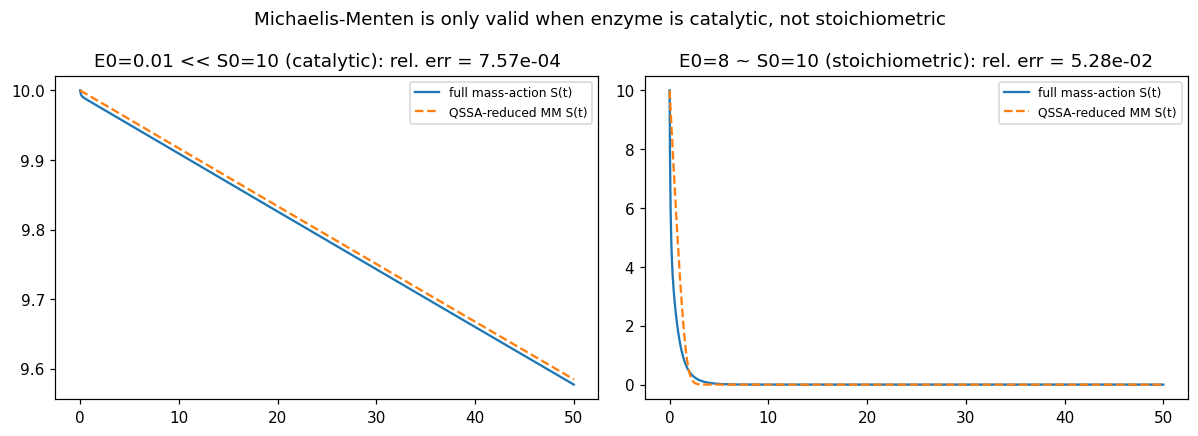

QSSA error ratio (bad/good): 69.7x worse


In [2]:
t = np.linspace(0, 50, 1500)

good = bk.qssa_validity(E0=0.01, S0=10.0, k1=1.0, k_minus1=1.0, k2=1.0, t=t)
bad  = bk.qssa_validity(E0=8.0,  S0=10.0, k1=1.0, k_minus1=1.0, k2=1.0, t=t)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, good["S_full"], label="full mass-action S(t)")
axes[0].plot(t, good["S_mm"], "--", label="QSSA-reduced MM S(t)")
axes[0].set_title(f"E0=0.01 << S0=10 (catalytic): rel. err = {good['rms_relative_error']:.2e}")
axes[0].legend(fontsize=8)

axes[1].plot(t, bad["S_full"], label="full mass-action S(t)")
axes[1].plot(t, bad["S_mm"], "--", label="QSSA-reduced MM S(t)")
axes[1].set_title(f"E0=8 ~ S0=10 (stoichiometric): rel. err = {bad['rms_relative_error']:.2e}")
axes[1].legend(fontsize=8)
fig.suptitle("Michaelis-Menten is only valid when enzyme is catalytic, not stoichiometric")
fig.tight_layout()
plt.show()

print(f"QSSA error ratio (bad/good): {bad['rms_relative_error']/good['rms_relative_error']:.1f}x worse")


## 2. Saturation kinetics and cooperativity (Hill equation)

The Hill equation $v = V_{max}S^n/(K^n+S^n)$ generalizes MM: $n=1$ reduces
exactly to Michaelis-Menten, $n>1$ gives the sigmoidal cooperative-binding
curve real allosteric enzymes (and hemoglobin-O2) show.


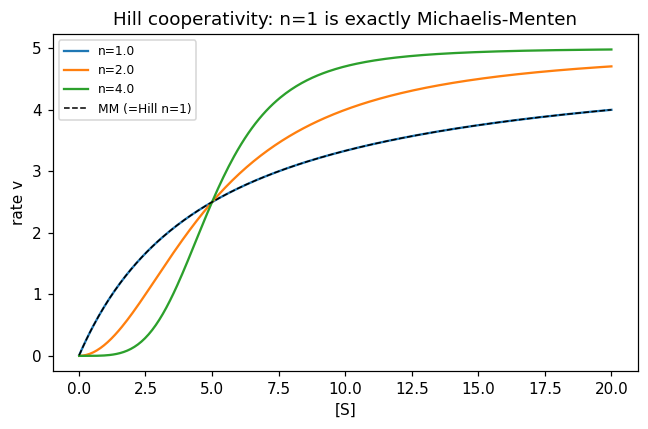

In [3]:
S = np.linspace(0.01, 20, 300)
plt.figure(figsize=(6, 4))
for n in [1.0, 2.0, 4.0]:
    plt.plot(S, bk.hill_equation(S, Vmax=5.0, K=5.0, n=n), label=f"n={n}")
plt.plot(S, bk.michaelis_menten_rate(S, Vmax=5.0, Km=5.0), "k--", lw=1, label="MM (=Hill n=1)")
plt.xlabel("[S]"); plt.ylabel("rate v")
plt.title("Hill cooperativity: n=1 is exactly Michaelis-Menten")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Competitive inhibition: Vmax unchanged, Km apparent rises


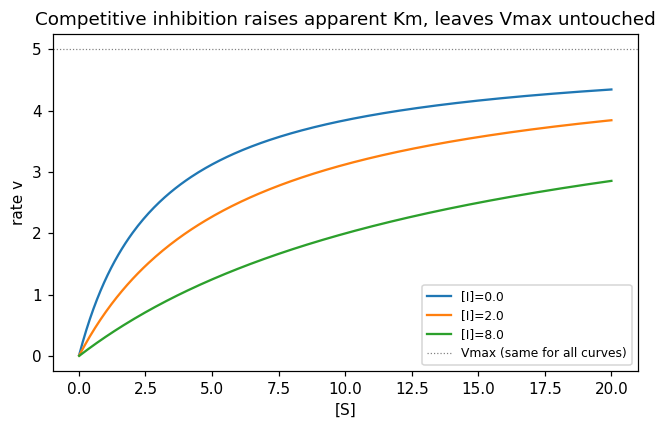

In [4]:
plt.figure(figsize=(6, 4))
for I in [0.0, 2.0, 8.0]:
    v = bk.competitive_inhibition_rate(S, I=I, Vmax=5.0, Km=3.0, Ki=2.0)
    plt.plot(S, v, label=f"[I]={I}")
plt.axhline(5.0, ls=":", color="gray", lw=0.8, label="Vmax (same for all curves)")
plt.xlabel("[S]"); plt.ylabel("rate v")
plt.title("Competitive inhibition raises apparent Km, leaves Vmax untouched")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Lineweaver-Burk: recovering Vmax, Km from rate data

Linearize $1/v = (K_m/V_{max})(1/S) + 1/V_{max}$ and solve the linear-
regression normal equations -- the classic graphical method for extracting
kinetic constants, done as an explicit least-squares solve.


true Vmax=7.5, Km=2.2
fit  Vmax=7.4956, Km=2.1913


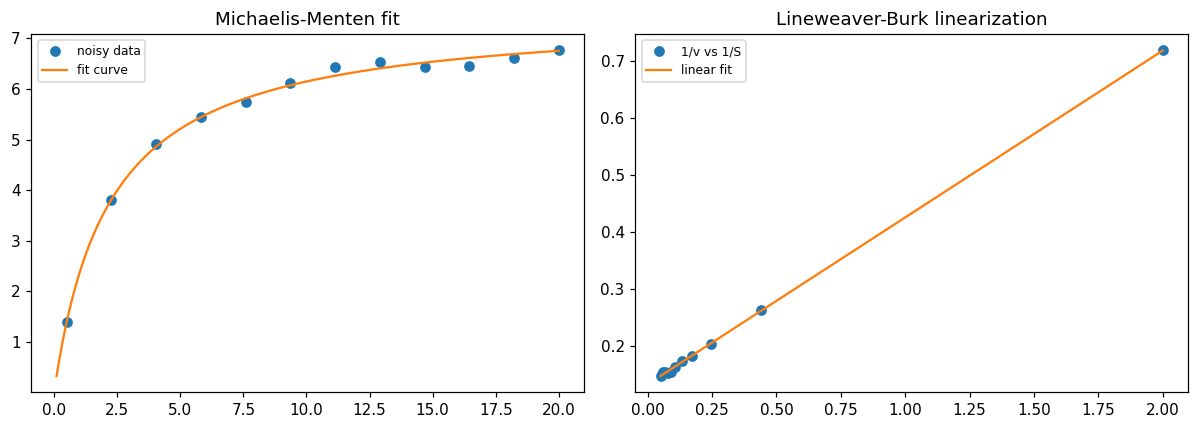

In [5]:
true_Vmax, true_Km = 7.5, 2.2
S2 = np.linspace(0.5, 20, 12)
rng = np.random.default_rng(0)
v2 = bk.michaelis_menten_rate(S2, true_Vmax, true_Km) * (1 + 0.02 * rng.standard_normal(S2.shape))

fit = bk.lineweaver_burk_fit(S2, v2)
print(f"true Vmax={true_Vmax}, Km={true_Km}")
print(f"fit  Vmax={fit['Vmax']:.4f}, Km={fit['Km']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(S2, v2, "o", label="noisy data")
S_fine = np.linspace(0.1, 20, 200)
axes[0].plot(S_fine, bk.michaelis_menten_rate(S_fine, fit["Vmax"], fit["Km"]), label="fit curve")
axes[0].set_title("Michaelis-Menten fit"); axes[0].legend(fontsize=8)

axes[1].plot(1 / S2, 1 / v2, "o", label="1/v vs 1/S")
x_fine = np.linspace(min(1 / S2), max(1 / S2), 50)
axes[1].plot(x_fine, fit["slope"] * x_fine + fit["intercept"], label="linear fit")
axes[1].set_title("Lineweaver-Burk linearization"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Summary

The Michaelis-Menten rate law isn't a postulate here -- it's the output of
integrating the real 4-species elementary mechanism with RK4 and applying
the quasi-steady-state approximation, with the approximation's validity
checked directly (catalytic enzyme: <0.1% error; stoichiometric enzyme: 70x
worse). Hill cooperativity, competitive inhibition, and the Lineweaver-Burk
linear-regression fit round out the classic differential-equations toolkit
biochemistry actually runs on.
